# Dataset Generation

Outline
- 2.1 Load Phase 1 environment
- 2.2 Generate Cleaner training samples (target: 5,480)
- 2.3 Generate Router training samples (target: 43,400)
- 2.4 Dataset statistics & validation
- 2.5 Serialize datasets to disk

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import itertools
import random
import pickle
import os
from copy import deepcopy
from typing import List, Tuple, Dict, Optional
from tqdm.notebook import tqdm

## 2.2: Cleaner Dataset Generation

**Goal:** For each routed configuration with overlaps, record which net the Cleaner should remove.

Each sample: `(state_tensor, label)` where label = index of net to remove (0, 1, or 2).

**Labeling strategy:** the net with the most cells involved in overlaps is the best removal candidate.

In [2]:
from routing_env import *

all_configs_m2 = generate_net_configs(min_manhattan=2, seed=42)

def compute_overlaps_strict(state, nets):
    pin_cells = set()
    for src, snk in nets:
        pin_cells.add(src)
        pin_cells.add(snk)
    congestion = state[C_CONGESTION]
    count = 0
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if congestion[r, c] > 1 and (r, c) not in pin_cells:
                count += 1
    return count

real_overlap_configs = []
for cfg in all_configs_m2:
    nets  = deepcopy(cfg)
    paths = route_all_nets_astar(GRID_SIZE, nets)
    state = build_state_tensor(nets, paths, GRID_SIZE)
    if compute_overlaps_strict(state, nets) > 0:
        real_overlap_configs.append(cfg)

all_configs = real_overlap_configs
print(f"Working configs : {len(all_configs)}")
print("Environment loaded")

gymnasium available
NumPy: 2.2.6
All imports OK
Grid: 5×5  |  Nets: 3  |  Channels: 7
State tensor shape: (7, 5, 5)
Working configs : 5000
Environment loaded


In [3]:
def label_cleaner_sample(state, paths, nets, rng=None):
    """
    Label = the net whose removal + A* re-route yields zero strict overlaps.
    This matches exactly what we measure in evaluation.
    """
    # Build pin cells for strict overlap check
    pin_cells = set()
    for src, snk in nets:
        pin_cells.add(src)
        pin_cells.add(snk)

    indices = list(range(NUM_NETS))
    if rng is not None:
        rng.shuffle(indices)

    for net_idx in indices:
        if paths[net_idx] is None:
            continue
        # Remove this net and try A* re-route
        blocked = set()
        for i, p in enumerate(paths):
            if p and i != net_idx:
                for cell in p:
                    blocked.add(cell)
        src, snk = nets[net_idx]
        blocked.discard(src)
        blocked.discard(snk)
        new_path = astar(GRID_SIZE, src, snk, blocked=blocked)
        if new_path is None:
            continue
        # Check if re-routing resolves strict overlaps
        test_paths = list(paths)
        test_paths[net_idx] = new_path
        test_state = build_state_tensor(nets, test_paths, GRID_SIZE)
        strict_ov  = sum(
            1 for r in range(GRID_SIZE) for c in range(GRID_SIZE)
            if test_state[C_CONGESTION][r, c] > 1 and (r, c) not in pin_cells
        )
        if strict_ov == 0:
            return net_idx

    return None  # no single net removal can fix this config


def generate_cleaner_dataset(configs, samples_per_config=10, seed=42):
    rng = np.random.default_rng(seed)
    X, y = [], []

    for cfg in tqdm(configs, desc="Cleaner samples"):
        for _ in range(samples_per_config):
            order = list(range(NUM_NETS))
            rng.shuffle(order)
            shuffled_nets = [cfg[i] for i in order]

            paths = route_all_nets_astar(GRID_SIZE, shuffled_nets)
            state = build_state_tensor(shuffled_nets, paths, GRID_SIZE)

            label = label_cleaner_sample(state, paths, shuffled_nets, rng=rng)
            if label is None:
                continue

            X.append(state)
            y.append(label)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


cleaner_X, cleaner_y = generate_cleaner_dataset(
    configs=all_configs,
    samples_per_config=2,
    seed=42
)

print(f"\nCleaner Dataset")
print(f"  X shape : {cleaner_X.shape}")
print(f"  y shape : {cleaner_y.shape}")
print(f"  Samples : {len(cleaner_y)}")
print(f"  Label distribution:")
for net_idx in range(NUM_NETS):
    count = int(np.sum(cleaner_y == net_idx))
    pct = count / len(cleaner_y) * 100
    print(f"    Net {net_idx}: {count} samples ({pct:.1f}%)")

Cleaner samples:   0%|          | 0/5000 [00:00<?, ?it/s]


Cleaner Dataset
  X shape : (9428, 7, 5, 5)
  y shape : (9428,)
  Samples : 9428
  Label distribution:
    Net 0: 3166 samples (33.6%)
    Net 1: 3102 samples (32.9%)
    Net 2: 3160 samples (33.5%)


In [4]:
def path_to_mask(path, grid_size=GRID_SIZE):
    mask = np.zeros((grid_size, grid_size), dtype=np.float32)
    if path:
        for (r, c) in path:
            mask[r, c] = 1.0
    return mask


def path_to_action_sequence(path):
    actions = []
    for i in range(len(path) - 1):
        dr = path[i+1][0] - path[i][0]
        dc = path[i+1][1] - path[i][1]
        if   (dr, dc) == (-1,  0): actions.append(0)
        elif (dr, dc) == ( 1,  0): actions.append(1)
        elif (dr, dc) == ( 0, -1): actions.append(2)
        elif (dr, dc) == ( 0,  1): actions.append(3)
    return actions


def generate_router_dataset(configs, samples_per_config=114, seed=42):
    rng = np.random.default_rng(seed)
    samples = []

    for cfg in tqdm(configs, desc="Router samples"):
        for _ in range(samples_per_config):
            order = list(range(NUM_NETS))
            rng.shuffle(order)
            shuffled_nets = [cfg[i] for i in order]

            paths = route_all_nets_astar(GRID_SIZE, shuffled_nets)
            state = build_state_tensor(shuffled_nets, paths, GRID_SIZE)

            net_to_remove = label_cleaner_sample(state, paths, shuffled_nets, rng=rng)
            if net_to_remove is None:
                continue

            partial_paths = deepcopy(paths)
            partial_paths[net_to_remove] = None
            partial_state = build_state_tensor(shuffled_nets, partial_paths, GRID_SIZE)

            blocked = set()
            for i, p in enumerate(partial_paths):
                if p and i != net_to_remove:
                    for cell in p:
                        blocked.add(cell)
            src, snk = shuffled_nets[net_to_remove]
            blocked.discard(src)
            blocked.discard(snk)

            optimal_path = astar(GRID_SIZE, src, snk, blocked=blocked)
            if optimal_path is None:
                continue

            samples.append({
                "state":       partial_state,
                "net_idx":     net_to_remove,
                "target_mask": path_to_mask(optimal_path),
                "action_seq":  path_to_action_sequence(optimal_path),
                "path_length": len(optimal_path) - 1,
            })

    return samples


router_samples = generate_router_dataset(
    configs=all_configs,
    samples_per_config=9,
    seed=42
)

print(f"\nRouter Dataset")
print(f"  Total samples : {len(router_samples)}")
path_lengths = [s['path_length'] for s in router_samples]
print(f"  Path length stats:")
print(f"    Min  : {np.min(path_lengths)}")
print(f"    Max  : {np.max(path_lengths)}")
print(f"    Mean : {np.mean(path_lengths):.2f}")

Router samples:   0%|          | 0/5000 [00:00<?, ?it/s]


Router Dataset
  Total samples : 42426
  Path length stats:
    Min  : 3
    Max  : 14
    Mean : 4.89


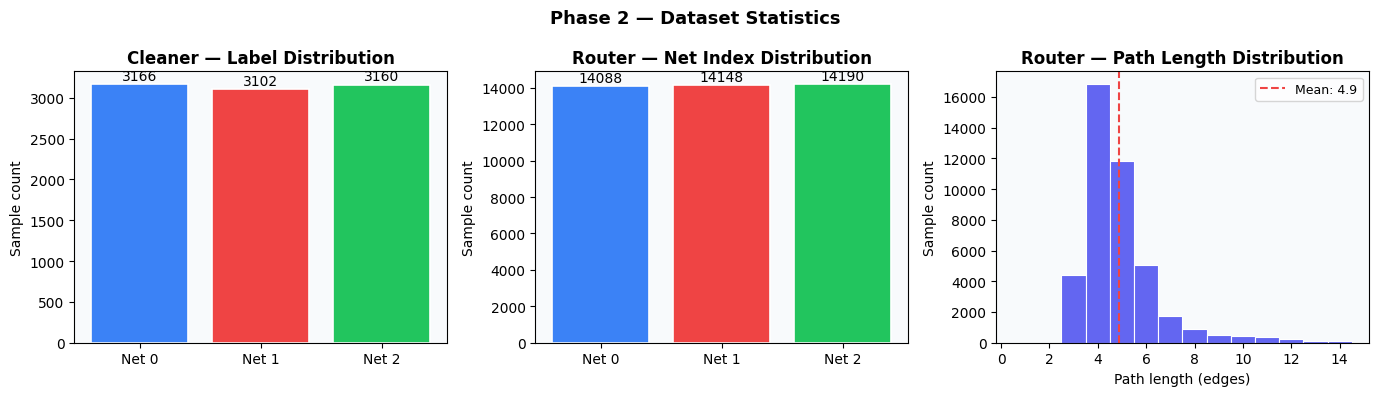

Dataset statistics plot saved


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Phase 2 — Dataset Statistics", fontsize=13, fontweight='bold')

# Plot 1: Cleaner label distribution
ax = axes[0]
counts = [int(np.sum(cleaner_y == i)) for i in range(NUM_NETS)]
bars = ax.bar([f'Net {i}' for i in range(NUM_NETS)], counts,
              color=['#3B82F6','#EF4444','#22C55E'], edgecolor='white', linewidth=1.2)
ax.set_title('Cleaner — Label Distribution', fontweight='bold')
ax.set_ylabel('Sample count')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha='center', va='bottom', fontsize=10)
ax.set_facecolor('#F8FAFC')

# Plot 2: Router net index distribution
ax = axes[1]
net_counts = [sum(1 for s in router_samples if s['net_idx'] == i) for i in range(NUM_NETS)]
bars = ax.bar([f'Net {i}' for i in range(NUM_NETS)], net_counts,
              color=['#3B82F6','#EF4444','#22C55E'], edgecolor='white', linewidth=1.2)
ax.set_title('Router — Net Index Distribution', fontweight='bold')
ax.set_ylabel('Sample count')
for bar, count in zip(bars, net_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=10)
ax.set_facecolor('#F8FAFC')

# Plot 3: Router path length histogram
ax = axes[2]
ax.hist(path_lengths, bins=range(1, max(path_lengths)+2),
        color='#6366F1', edgecolor='white', linewidth=0.8, align='left')
ax.set_title('Router — Path Length Distribution', fontweight='bold')
ax.set_xlabel('Path length (edges)')
ax.set_ylabel('Sample count')
ax.axvline(np.mean(path_lengths), color='#EF4444', linestyle='--',
           linewidth=1.5, label=f'Mean: {np.mean(path_lengths):.1f}')
ax.legend(fontsize=9)
ax.set_facecolor('#F8FAFC')

plt.tight_layout()
plt.savefig('phase2_dataset_stats.png', dpi=120, bbox_inches='tight')
plt.show()
print("Dataset statistics plot saved")

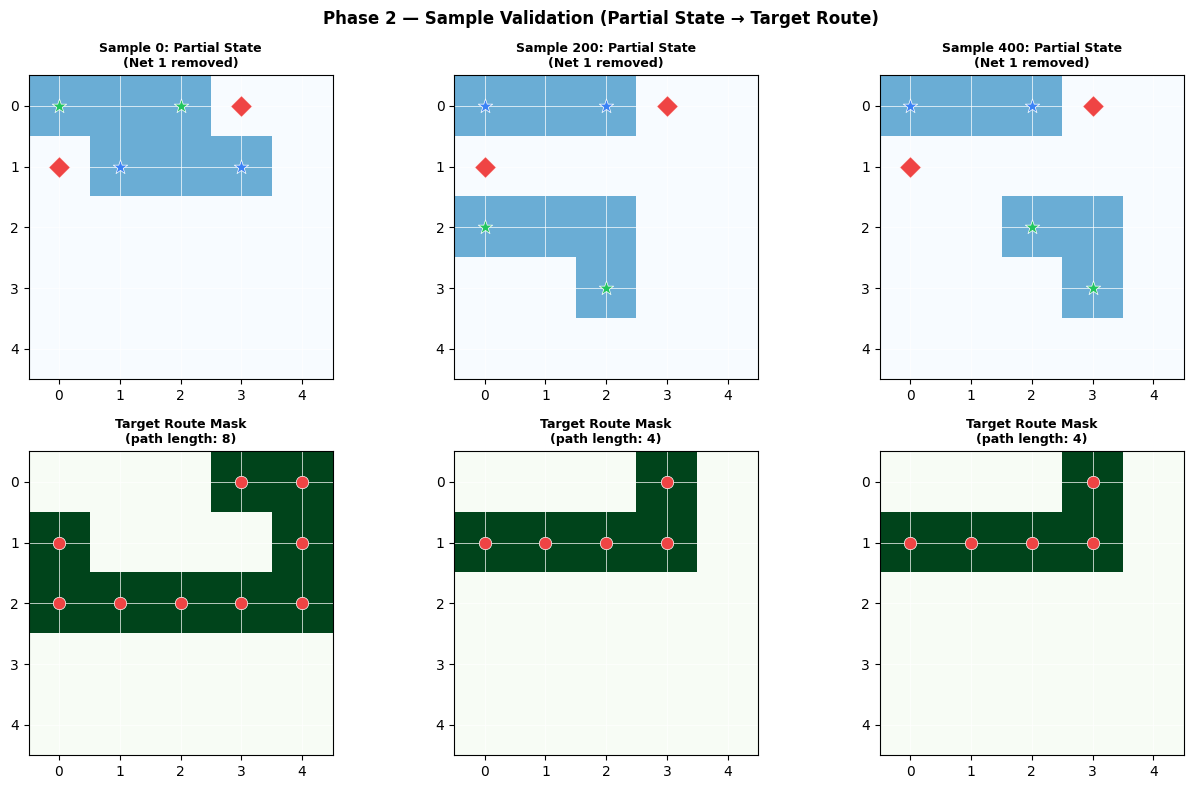

Sample validation plot saved


In [6]:
# Validate a few samples visually
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle("Phase 2 — Sample Validation (Partial State → Target Route)",
             fontsize=12, fontweight='bold')

NET_COLORS = ['#3B82F6', '#EF4444', '#22C55E']

for i in range(3):
    sample = router_samples[i * 200]  # spread across dataset
    state  = sample['state']
    mask   = sample['target_mask']
    net_idx = sample['net_idx']

    # Left: partial state (net removed)
    ax = axes[0, i]
    ax.imshow(state[C_CONGESTION], cmap='Blues', vmin=0, vmax=2, interpolation='nearest')
    for n in range(NUM_NETS):
        pin_layer = state[C_PIN_START + n]
        ys, xs = np.where(pin_layer > 0)
        ax.scatter(xs, ys, color=NET_COLORS[n], s=120,
                   marker='*' if n != net_idx else 'D',
                   zorder=5, edgecolors='white', linewidths=0.5)
    ax.set_title(f'Sample {i*200}: Partial State\n(Net {net_idx} removed)',
                 fontsize=9, fontweight='bold')
    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.grid(True, color='white', linewidth=0.5)

    # Right: target route mask
    ax = axes[1, i]
    ax.imshow(mask, cmap='Greens', vmin=0, vmax=1, interpolation='nearest')
    ys, xs = np.where(mask > 0)
    ax.scatter(xs, ys, color=NET_COLORS[net_idx], s=80,
               zorder=5, edgecolors='white', linewidths=0.5)
    ax.set_title(f'Target Route Mask\n(path length: {sample["path_length"]})',
                 fontsize=9, fontweight='bold')
    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.grid(True, color='white', linewidth=0.5)

plt.tight_layout()
plt.savefig('phase2_sample_validation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Sample validation plot saved")

In [7]:
import pickle, os
os.makedirs('data', exist_ok=True)

cleaner_data = {'X': cleaner_X, 'y': cleaner_y}
with open('data/cleaner_dataset.pkl', 'wb') as f:
    pickle.dump(cleaner_data, f)
print(f"Cleaner saved to data/cleaner_dataset.pkl")

with open('data/router_dataset.pkl', 'wb') as f:
    pickle.dump(router_samples, f)
print(f"Router saved  to data/router_dataset.pkl")

with open('data/net_configs.pkl', 'wb') as f:
    pickle.dump(all_configs, f)
print(f"Configs saved to data/net_configs.pkl")

Cleaner saved to data/cleaner_dataset.pkl
Router saved  to data/router_dataset.pkl
Configs saved to data/net_configs.pkl
